In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import eigh

## The Rayleigh-Ritz theorem in $\mathrm{R}^3$

Unit vectors in $\mathbb{R}^3$ can be parameterized as 

$$
x = 
\begin{bmatrix}
    \cos\theta \cos\phi \\
    \cos\theta \sin\phi \\
    \sin\theta
\end{bmatrix}
\qquad \theta \in [0,\pi) \quad \mbox{ and } \quad  \phi\in[0,2\pi).
$$

The following function uses this parameterization to plot a quadratic form $x^TAx$ on the unit sphere. 

In [2]:
def plot_quad_form(A):
    # generate m unit vectors
    m = 500
    
    theta = np.linspace(0, np.pi, m)
    phi = np.linspace(0, 2*np.pi, m)
    Theta, Phi = np.meshgrid(theta, phi)

    X = np.sin(Theta)*np.cos(Phi)
    Y = np.sin(Theta)*np.sin(Phi)
    Z = np.cos(Theta)

    uvect = np.stack([X.flatten(),Y.flatten(),Z.flatten()])
    
    # evaluate f on the unit sphere
    f = np.sum(uvect*(A.dot(uvect)),axis=0)
    f = f.reshape(Theta.shape)
    
    fig = plt.figure(figsize=(5,10))
    # plot f on the unit sphere
    ax = fig.add_subplot(2,1,1, projection='3d')
    img = ax.scatter(uvect[0],uvect[1],uvect[2], c=f, cmap=cm.coolwarm,alpha=0.2)
    
    # contour plot
    ax = fig.add_subplot(2, 1, 2)
    ax.contour(Theta,Phi,f, levels=20,cmap=cm.coolwarm)
    img = ax.contourf(Theta,Phi,f,levels=15,cmap=cm.coolwarm)
    fig.colorbar(img)
    ax.set_xlabel('Theta', fontsize=15)
    ax.set_ylabel('Phi', fontsize=15)
    ax.set_title('contour plot of f', fontsize=20)

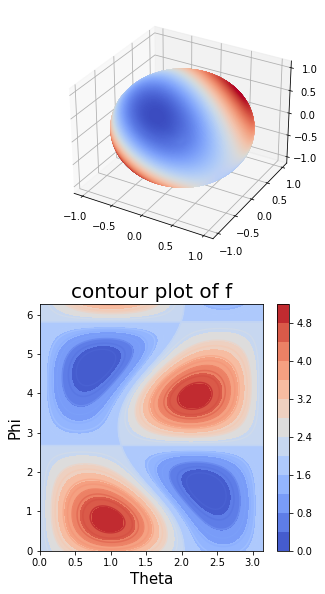

In [3]:
# example
A = np.array([[3,1,1],
             [1,2,2],
             [1,2,2]])
plot_quad_form(A)

How many maxima, minima and inflection points does $f$ have?

f has two maxima and two minima, which come in pairs of antipodal points. I'm honestly not certain but I would guess f has infinitely many inflection points along a pair of great circles.

Find four $3\times 3$ symmetric matrices: one with three distinct eigenvalues, one with a repeated (double) largest eigenvalues, one with a repeated (double) smallest eigenvalue, and one with a repeated (triple) eigenvalue.

Plot their corresponding quadratic forms. 

In [7]:
# matrix 1
A1 = np.array([[2,7,3],[7,2,5],[3,5,2]])

eigh(A1) #show three distinct eigenvalues

(array([-5.38735795, -0.79247604, 12.17983399]),
 array([[ 0.60528479, -0.53721065, -0.58739683],
        [-0.75139056, -0.14201048, -0.64439526],
        [ 0.26275949,  0.83140708, -0.4896118 ]]))

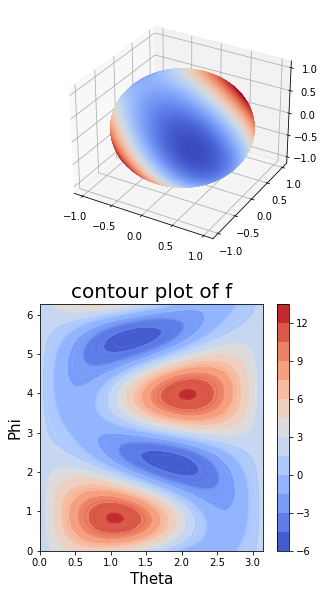

In [8]:
plot_quad_form(A1)

In [17]:
# matrix 2
A2 = np.array([[0,0,6],[0,6,0],[6,0,0]])

eigh(A2)

(array([-6.,  6.,  6.]),
 array([[ 0.70710678, -0.70710678,  0.        ],
        [ 0.        ,  0.        , -1.        ],
        [-0.70710678, -0.70710678,  0.        ]]))

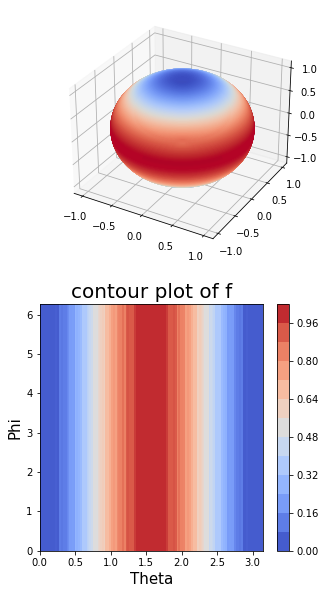

In [12]:
plot_quad_form(A2)

In [13]:
# matrix 3
A3 = np.array([[7,0,0],[0,0,0],[0,0,0]])

eigh(A3)

(array([0., 0., 7.]),
 array([[0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.]]))

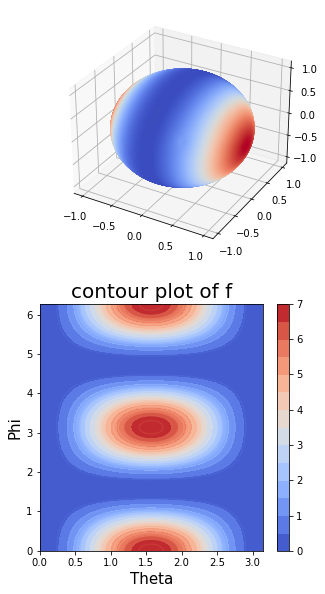

In [14]:
plot_quad_form(A3)

In [19]:
# matrix 4
A4 = np.array([[-6,0,0],[0,-6,0],[0,0,-6]])

eigh(A4)

(array([-6., -6., -6.]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))

<ipython-input-2-08f617b04e71>:26: UserWarning: No contour levels were found within the data range.
  ax.contour(Theta,Phi,f, levels=20,cmap=cm.coolwarm)


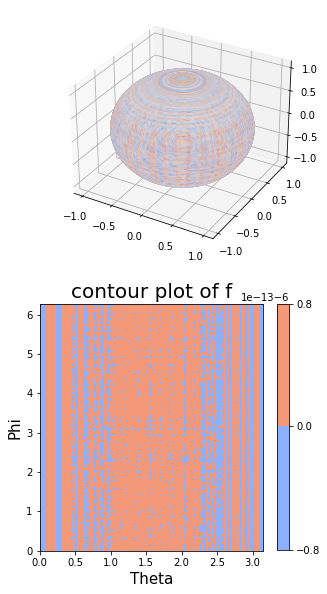

In [20]:
plot_quad_form(A4)